Lab-13: Build a neural network to classify handwritten digits – target 95%+ accuracy


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


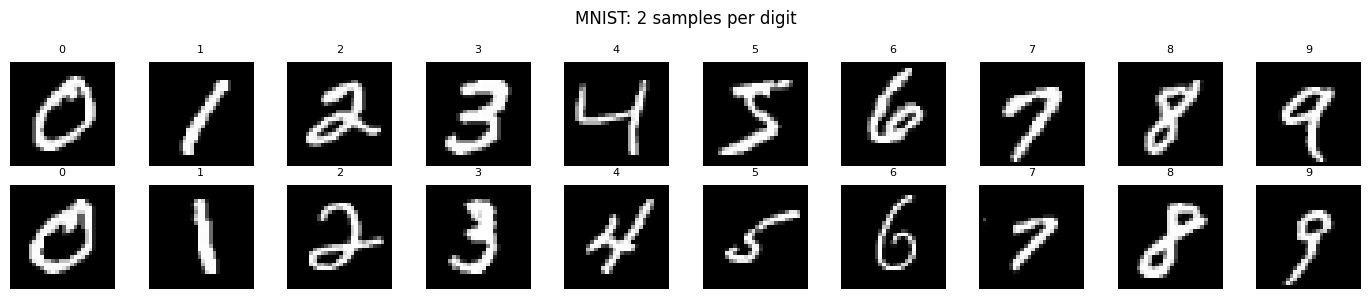

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for d in range(10):
  for r, offset in enumerate([0, 1]):
    idx = np.where(y_train == d)[0][offset]
    axes[r, d].imshow(X_train[idx].reshape(28,28), cmap='gray')
    axes[r, d].set_title(str(d), fontsize=8); axes[r, d].axis('off')
plt.suptitle('MNIST: 2 samples per digit'); plt.tight_layout(); plt.show()
def make_model(h1=256, h2=128, drop=0.3):
  m = keras.Sequential([
  keras.Input(shape=(784,)),
  layers.Dense(h1, activation='relu'),
  layers.Dropout(drop),
  layers.Dense(h2, activation='relu'),
                       layers.Dropout(drop),
  layers.Dense(10, activation='softmax'),
  ])
  m.compile(optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])
  return m
model = make_model()
model.summary()

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8761 - loss: 0.4029 - val_accuracy: 0.9637 - val_loss: 0.1248
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9470 - loss: 0.1768 - val_accuracy: 0.9718 - val_loss: 0.0888
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9599 - loss: 0.1323 - val_accuracy: 0.9743 - val_loss: 0.0776
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9677 - loss: 0.1063 - val_accuracy: 0.9798 - val_loss: 0.0687
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9721 - loss: 0.0906 - val_accuracy: 0.9813 - val_loss: 0.0648
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9760 - loss: 0.0795 - val_accuracy: 0.9835 - val_loss: 0.0619
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9777 - loss: 0.0715 - val_accuracy: 0.9807 - val_loss: 0.0686
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9799 - loss: 0.0642 - val_accurac

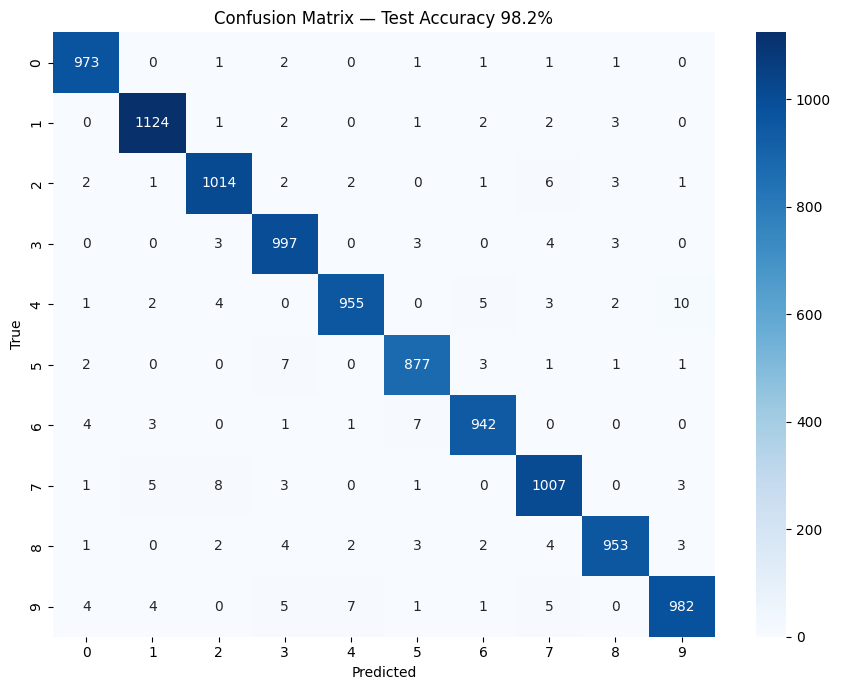

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.99      0.97      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

Misclassified: 176 out of 10000


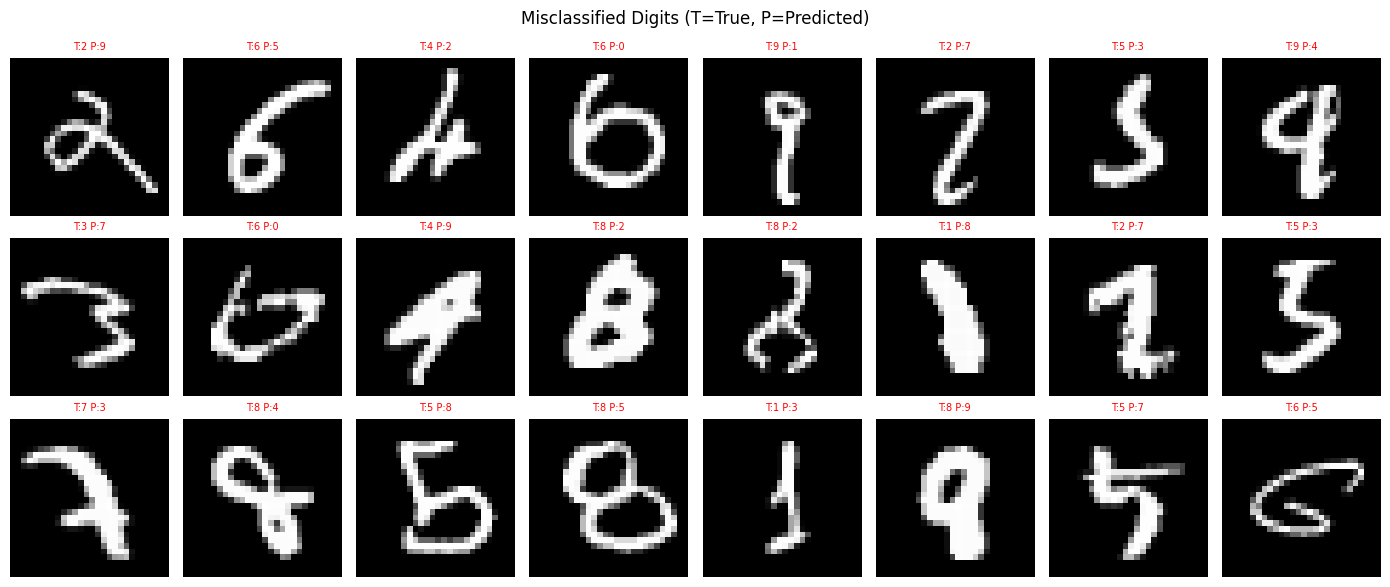

Large / moderate dropout            Accuracy: 97.98%


In [7]:
history = model.fit(
X_train, y_train, epochs=30, batch_size=128,
validation_split=0.1,
callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
verbose=1)
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {acc*100:.2f}%')
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix — Test Accuracy {acc*100:.1f}%')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred))
wrong = np.where(y_pred != y_test)[0]
print(f'Misclassified: {len(wrong)} out of {len(y_test)}')
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
  if i < len(wrong):
    idx = wrong[i]
    ax.imshow(X_test[idx].reshape(28,28), cmap='gray')
    ax.set_title(f'T:{y_test[idx]} P:{y_pred[idx]}',
    color='red', fontsize=7)
  ax.axis('off')
plt.suptitle('Misclassified Digits (T=True, P=Predicted)')
plt.tight_layout(); plt.show()
configs = [
(64, 32, 0.0, 'Small / no dropout'),
(128, 64, 0.2, 'Medium / light dropout'),
(256, 128, 0.3, 'Large / moderate dropout'),
]
for h1, h2, dr, label in configs:
  m = make_model(h1, h2, dr)
  m.fit(X_train, y_train, epochs=15, batch_size=128,
    validation_split=0.1, verbose=0,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])
_, a = m.evaluate(X_test, y_test, verbose=0)
print(f'{label:35s} Accuracy: {a*100:.2f}%')

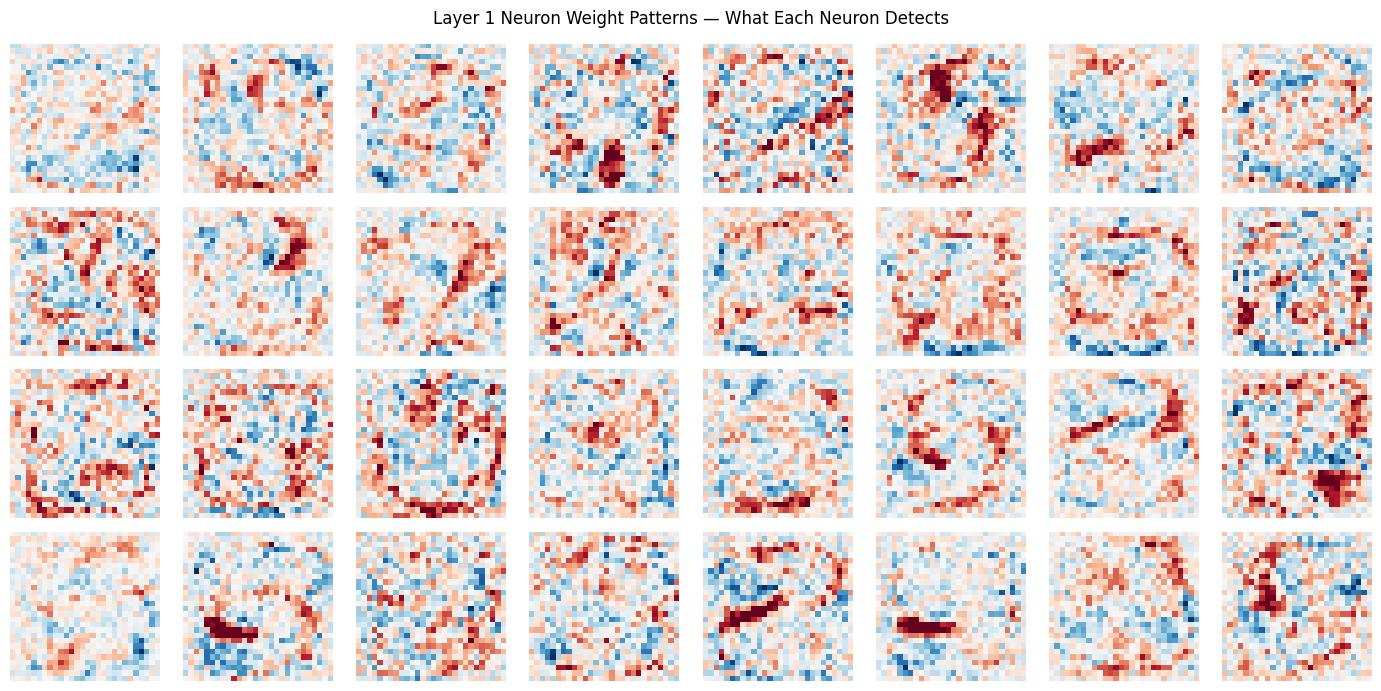

In [8]:
weights = model.layers[0].get_weights()[0]
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
  w = weights[:, i].reshape(28, 28)
  ax.imshow(w, cmap='RdBu', vmin=-w.max(), vmax=w.max())
  ax.axis('off')
plt.suptitle('Layer 1 Neuron Weight Patterns — What Each Neuron Detects')
plt.tight_layout(); plt.show()
